In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

from inferencia import load_model
from preprocessing import normalize_image
from watershed import watershed_from_logits


CHECKPOINT = "checkpoints/unet_boundary.pth"

INTERIOR_THRESHOLD = 0.5
FOREGROUND_THRESHOLD = 0.5
MIN_MARKER_SIZE = 10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


In [2]:
IMAGE_PATH = "data/synthetic/0000/image.png"

print("Imagem:", IMAGE_PATH)

Imagem: data/synthetic/0000/image.png


In [3]:
model = load_model(CHECKPOINT)

print("Modelo carregado com sucesso.")

Modelo carregado com sucesso.


In [4]:
def prepare_input(image_path):
    """
    Carrega uma imagem, converte para escala de cinza,
    normaliza para [0, 1] e cria o tensor [1, 1, H, W].
    """

    image = Image.open(image_path).convert("L")

    image_array = np.array(image)

    image_tensor = torch.from_numpy(
        image_array
    ).float()

    image_tensor = normalize_image(
        image_tensor
    )

    if image_tensor.ndim == 2:
        image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.unsqueeze(0)

    return image, image_tensor

In [5]:
def infer_image(image_path):
    """
    Executa a inferência completa:

    imagem
        ↓
    U-Net
        ↓
    logits de background/interior/boundary
        ↓
    watershed
        ↓
    máscara de instâncias
    """

    original_image, image_tensor = prepare_input(
        image_path
    )

    image_tensor = image_tensor.to(DEVICE)

    with torch.no_grad():
        logits = model(image_tensor)

    instance_mask, markers, foreground_mask = (
        watershed_from_logits(
            logits[0],
            interior_threshold=INTERIOR_THRESHOLD,
            foreground_threshold=FOREGROUND_THRESHOLD,
            min_marker_size=MIN_MARKER_SIZE
        )
    )

    instance_ids = np.unique(instance_mask)
    instance_ids = instance_ids[
        instance_ids != 0
    ]

    count = len(instance_ids)

    return {
        "image": original_image,
        "instance_mask": instance_mask,
        "markers": markers,
        "foreground_mask": foreground_mask,
        "logits": logits[0].cpu(),
        "count": count
    }

In [6]:
result = infer_image(IMAGE_PATH)

print(
    f"Instâncias detectadas: {result['count']}"
)

Instâncias detectadas: 6


In [7]:
def colorize_instances(instance_mask):
    """
    Cria uma imagem RGB em que:
    - background = preto
    - cada instância = uma cor diferente
    """

    height, width = instance_mask.shape

    colored = np.zeros(
        (height, width, 3),
        dtype=np.float32
    )

    instance_ids = np.unique(
        instance_mask
    )
    instance_ids = instance_ids[
        instance_ids != 0
    ]

    cmap = plt.get_cmap("tab20")

    for index, instance_id in enumerate(instance_ids):
        color = cmap(
            index % 20
        )[:3]

        colored[
            instance_mask == instance_id
        ] = color

    return colored

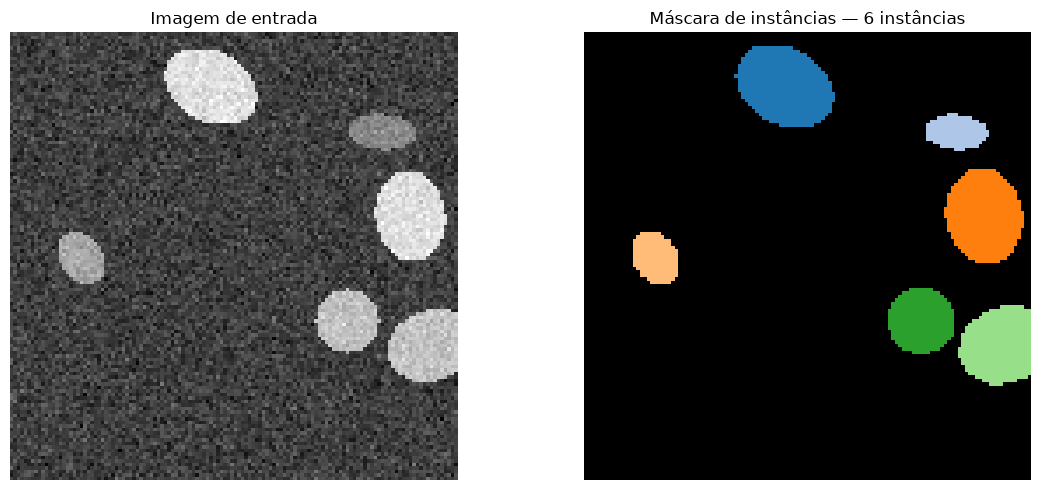

In [8]:
colored_mask = colorize_instances(
    result["instance_mask"]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(
    result["image"],
    cmap="gray"
)

axes[0].set_title(
    "Imagem de entrada"
)

axes[0].axis("off")


axes[1].imshow(
    colored_mask
)

axes[1].set_title(
    f"Máscara de instâncias — "
    f"{result['count']} instâncias"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()

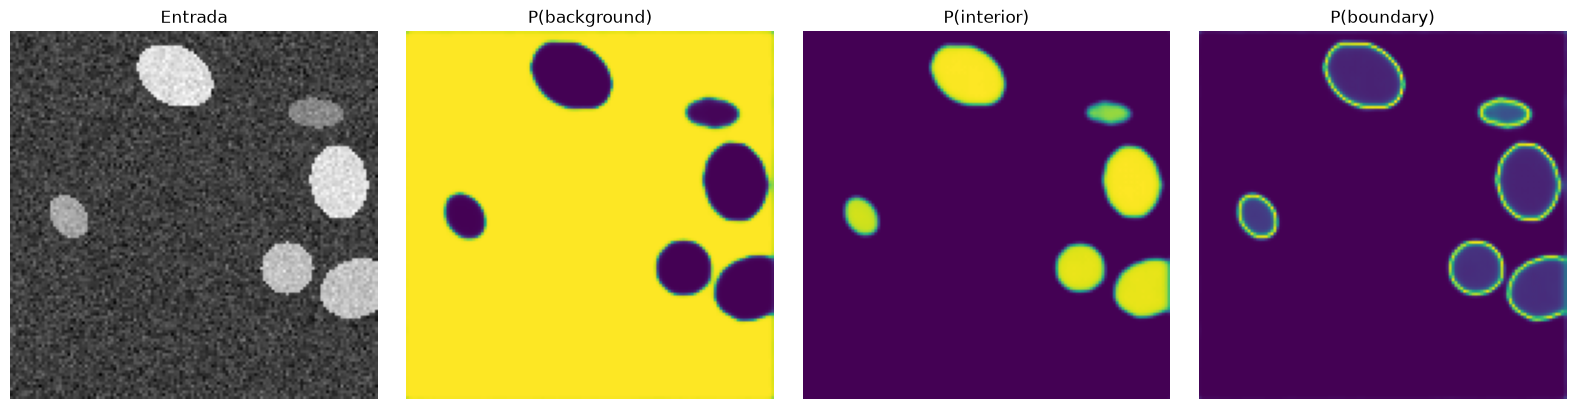

In [9]:
logits = result["logits"]

probabilities = torch.softmax(
    logits,
    dim=0
).numpy()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

axes[0].imshow(
    result["image"],
    cmap="gray"
)
axes[0].set_title("Entrada")


axes[1].imshow(
    probabilities[0],
    cmap="viridis"
)
axes[1].set_title("P(background)")


axes[2].imshow(
    probabilities[1],
    cmap="viridis"
)
axes[2].set_title("P(interior)")


axes[3].imshow(
    probabilities[2],
    cmap="viridis"
)
axes[3].set_title("P(boundary)")


for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
print(
    "Marcadores encontrados:",
    len(np.unique(result["markers"])) - 1
)

print(
    "Instâncias finais:",
    result["count"]
)

Marcadores encontrados: 6
Instâncias finais: 6
